# 3장 2강: 피어슨 상관계수의 의미와 한계 — 실습문제

## 실습 목표

- 두 연속형 변수의 피어슨 상관계수와 p-value를 계산하고 방향·강도를 해석합니다.
- 결정계수 $r^2$의 의미를 올바르게 설명합니다.
- 산점도를 함께 확인하여 이상치와 비선형 관계가 피어슨 상관계수에 미치는 영향을 판단합니다.
- 상관관계만으로 인과관계를 주장할 수 없는 이유와 가능한 혼란변수를 설명합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, SciPy, Matplotlib
- `ames_housing.csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `LotArea`
- 모든 판단은 유의수준 $\alpha=0.05$를 기준으로 합니다.

## 실습 준비

아래 셀을 실행해 데이터를 불러오고 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("ames_housing.csv")

alpha = 0.05

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()

데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적과 매매가격의 피어슨 상관분석

`GrLivArea`와 `SalePrice`의 선형 관계를 분석하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. `stats.pearsonr()`로 피어슨 상관계수 $r$과 p-value를 계산하세요.
3. $r^2$을 계산하세요.
4. 축 이름과 제목이 있는 산점도를 그리세요.
5. 아래 질문에 문장으로 답하세요.

### 질문

- 상관관계의 방향과 강도는 어떠한가요?
-> r값이 양수값이고 절대값이 0.71이므로 비교적 강한 양의 상관관계

- p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
-> p-value가 0.05보다 작으므로 상관계수가 0일 것 이라는 귀무가설을 기각한다.
-> 즉 두 변수는 통계적으로 유의하다.

- $r^2$은 이 관계에서 무엇을 의미하나요?
-> 같은 자료에 생활면적을 설명변수로 하는 절편을 포함하여 최소제곱 단순 선형회귀를 적합하여 결정계수 
-> r^2이 약 0.50이다.
-> 즉, 생활면적을 이용한 직선 모형이 이 자료의 가격 변동을 약 50.2% 설명한다. 

- 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?
-> 아닙니다. 이미 존재하는 주택의 특성을 관찰한 데이터에서 다른 외부 요인 변수를 분리하여 확인하지 못했다

표본 수: 1460
Pearson r = 0.7086
p-value = 4.5180e-223
r² = 0.5021
유의성 판단: 유의함


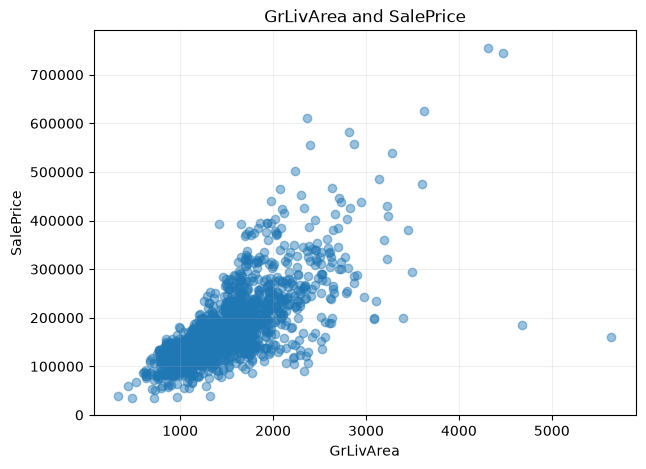

In [2]:
# 여기에 코드를 작성하세요.
area_price = df[["GrLivArea", "SalePrice"]].dropna()

r_area, p_area = stats.pearsonr(area_price["GrLivArea"], area_price["SalePrice"])
r2_area = r_area ** 2

print(f"표본 수: {len(area_price)}")
print(f"Pearson r = {r_area:.4f}")
print(f"p-value = {p_area:.4e}")
print(f"r² = {r2_area:.4f}")
print("유의성 판단:", "유의함" if p_area <= alpha else "유의하지 않음")

plt.figure(figsize=(7, 5))
plt.scatter(area_price["GrLivArea"], area_price["SalePrice"], alpha=0.45)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea and SalePrice")
plt.grid(alpha=0.2)
plt.show()


---

## 필수 2. 피어슨 상관계수의 두 가지 한계 확인

피어슨 상관계수가 이상치에 민감하고 비선형 관계를 놓칠 수 있다는 점을 확인하세요.

### A. 이상치의 영향

1. `GrLivArea`, `SalePrice`에서 `random_state=42`로 50행을 표본 추출하세요.
2. 표본의 $r$과 p-value를 계산하세요.
3. 학습용 가상 이상치 `(GrLivArea=6000, SalePrice=50000)` 한 행을 표본에만 추가하세요. 원본 `df`는 변경하지 마세요.
4. 이상치 추가 후 $r$과 p-value를 다시 계산하세요.
5. 추가 전후 산점도를 나란히 그리고 결과를 비교하세요.

### B. 비선형 관계

1. `x = [-3, -2, -1, 0, 1, 2, 3]`, `y = x**2`를 만드세요.
2. $x$와 $y$의 $r$과 p-value를 계산하고 산점도를 그리세요.

### 질문

- 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
-> r 0.71 -> 0.26으로 감소, p-value는 0.05미만에서 0.06으로 증가했다.
-> 귀무가설을 기각함에서 귀무가설을 기각할 수 없음으로 판단이 변경

- 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
-> 요약값만 보면 변화의 원인을 한 눈에 파악하기 어려움
-> 산점도는 멀리 떨어진 점들과 일부 선형관계를 한 눈에 파악하기 쉬움
-> 이 점은 이상치도 한 눈에 파악하기 쉽다는 것을 알려줌

- $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
-> 피어슨 r은 직선형태의 관계를 요악함
-> U자형 그래프의 왼쪽과 오른쪽은 서로 반대방향의 선형 움직임을 보이기 때문에 0에 가까움 

- `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?
-> 아닙니다. r ≈ 0은 선형관계가 거의 없다는 뜻, 비선형 관계는 존재할 수 있다. 

[이상치 추가 전]
r = 0.7059, p-value = 1.0263e-08
[이상치 추가 후]
r = 0.2602, p-value = 0.0651


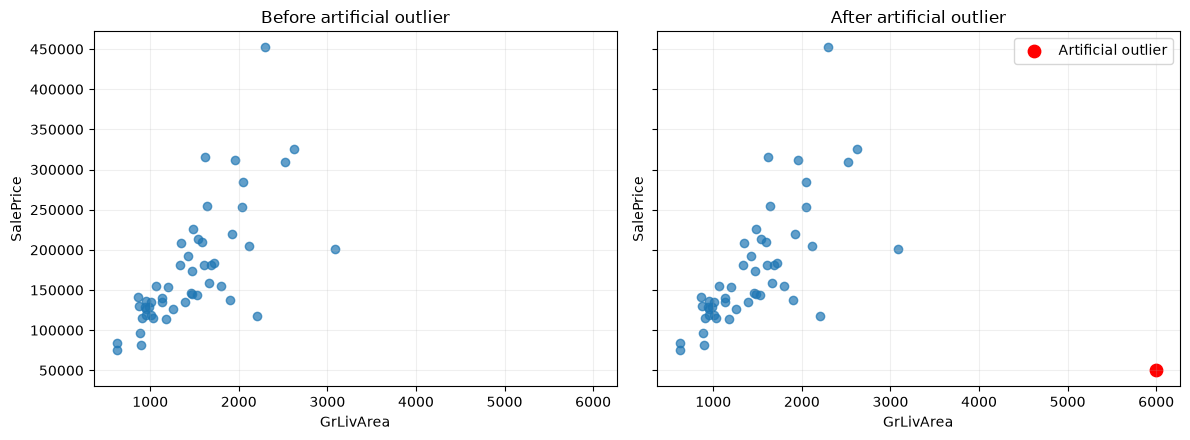


[비선형 관계 y=x²]
r = 0.0000, p-value = 1.0000


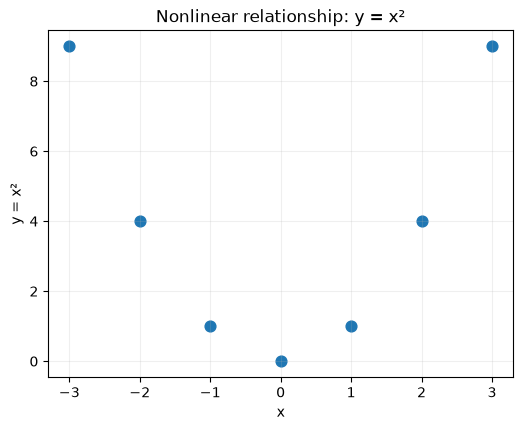

In [3]:
# 여기에 코드를 작성하세요.
# A. 이상치의 영향
sample_50 = df[["GrLivArea", "SalePrice"]].sample(50, random_state=42).copy()
r_before, p_before = stats.pearsonr(sample_50["GrLivArea"], sample_50["SalePrice"])

artificial_outlier = pd.DataFrame({"GrLivArea": [6000], "SalePrice": [50000]})
sample_with_outlier = pd.concat([sample_50, artificial_outlier], ignore_index=True)
r_after, p_after = stats.pearsonr(
    sample_with_outlier["GrLivArea"], sample_with_outlier["SalePrice"])

print("[이상치 추가 전]")
print(f"r = {r_before:.4f}, p-value = {p_before:.4e}")
print("[이상치 추가 후]")
print(f"r = {r_after:.4f}, p-value = {p_after:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
axes[0].scatter(sample_50["GrLivArea"], sample_50["SalePrice"], alpha=0.7)
axes[0].set_title("Before artificial outlier")
axes[1].scatter(sample_with_outlier["GrLivArea"], sample_with_outlier["SalePrice"], alpha=0.7)
axes[1].scatter([6000], [50000], color="red", s=80, label="Artificial outlier")
axes[1].set_title("After artificial outlier")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("GrLivArea")
    ax.set_ylabel("SalePrice")
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# B. 비선형 관계
x = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)
y = x ** 2
r_curve, p_curve = stats.pearsonr(x, y)

print("\n[비선형 관계 y=x²]")
print(f"r = {r_curve:.4f}, p-value = {p_curve:.4f}")

plt.figure(figsize=(6, 4.5))
plt.scatter(x, y, s=60)
plt.xlabel("x")
plt.ylabel("y = x²")
plt.title("Nonlinear relationship: y = x²")
plt.grid(alpha=0.2)
plt.show()


---

## 과제. 대지면적과 매매가격의 관계를 근거 있게 보고하기

`LotArea`와 `SalePrice`의 관계를 분석하고, 상관과 인과를 구별한 짧은 분석 보고를 작성하세요.

### 수행 요구사항

1. 두 변수의 피어슨 상관계수, p-value, $r^2$을 계산하세요.
2. 산점도를 그려 관계의 형태와 이상치 여부를 확인하세요.
3. 유의수준 0.05에서 통계적 유의성을 판단하세요.
4. 아래 질문에 빠짐없이 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 관계의 방향과 강도는 어떠한가요? 
--> r = 0.2638로 양의 방향이다. 대지면적이 넓을수록 매매가격이 높아지는 관계로 볼 수 있다.

- 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요? 
--> 아니오. p-value = 1.1231e-24로 0.05보다 작은데 상관계수가 0이라는 귀무가설을 기각한다.
--> r² = 0.0696로 대지면적으로 인한 가격변동은 약 7%정도로 확인된다.
--> p-value는 관계가 있다고 볼 수 있는지, r과 r²은 얼마나 연관이 있는지를 파악한다. 유의하다는 것만으로 강한 관계라고 볼 수 없다.

- 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요? 
--> 이 결과만으로는 내릴 수 없다. 상관계수는 대지면적과 매매가격이 함께 움직인다는 것을 보여줄 뿐, 매매가격의 상승원인이 무엇인지 구분해주지 못하기 때문이다.

- 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.
--> Neighborhood, GrLivArea

- 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.
--> 안 된다. 피어슨 상관계수는 직선 형태의 관계만 측정하는데, U자형에서는 양쪽이 서로 상쇄되어 r = 0으로 나온다. r = 0은 직선 관계가 없다는 뜻이지 아무 관계도 없다는 뜻이 아니므로 산점도를 함께 봐야 한다.


표본 수: 1460
Pearson r = 0.2638
p-value = 1.1231e-24
r² = 0.0696
유의성 판단: 유의함


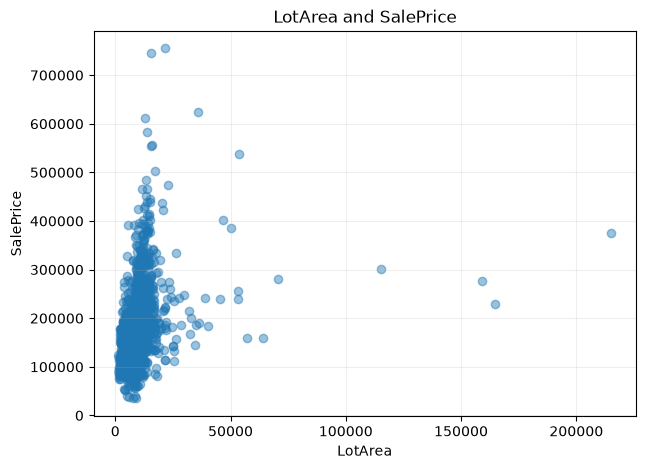

['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalePrice     1460 non-null   int64
 1   GrLivArea     1460 non-null   int64
 2   LotArea       1460 non-null   int64
 3   OverallQual   1460 non-null   int64
 4   KitchenQual   1460 non-null   str  
 5   CentralAir    1460 non-null   str  
 6   HeatingQC     1460 non-null   str  
 7   PavedDrive    1460 non-null   str  
 8   Neighborhood  1460 non-null   str  
 9   YearBuilt     1460 non-null   int64
dtypes: int64(5), str(5)
memory usage: 114.2 KB
SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
YearBuilt      0.522897
LotArea        0.263843
Name: SalePrice, dtype: float64
LotArea        1.000000
SalePrice      0.263843
GrLivArea      0.263116
Ov

In [ ]:
# 여기에 코드를 작성하세요.
lot_price = df[["LotArea", "SalePrice"]].dropna()

r_lot, p_lot = stats.pearsonr(lot_price["LotArea"], lot_price["SalePrice"])
r2_lot = r_lot ** 2

print(f"표본 수: {len(lot_price)}")
print(f"Pearson r = {r_lot:.4f}")
print(f"p-value = {p_lot:.4e}")
print(f"r² = {r2_lot:.4f}")
print("유의성 판단:", "유의함" if p_lot <= alpha else "유의하지 않음")

plt.figure(figsize=(7, 5))
plt.scatter(lot_price["LotArea"], lot_price["SalePrice"], alpha=0.45)
plt.xlabel("LotArea")
plt.ylabel("SalePrice")
plt.title("LotArea and SalePrice")
plt.grid(alpha=0.2)
plt.show()

print(df.columns.tolist())
df.info()
df.describe()


In [6]:
# 숫자 컬럼끼리의 상관계수 한 번에 보기
print(df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False))
print(df.corr(numeric_only=True)["LotArea"].sort_values(ascending=False))

# 범주형 컬럼이 연속형 변수를 얼마나 설명하는지 (eta²)
def eta_squared(df, cat_col, num_col):
    data = df[[cat_col, num_col]].dropna()
    groups = [g[num_col] for _, g in data.groupby(cat_col)]

    grand_mean = data[num_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((data[num_col] - grand_mean) ** 2).sum()

    f_stat, p_value = stats.f_oneway(*groups)
    return ss_between / ss_total, p_value, data[cat_col].nunique()


cat_cols = ["Neighborhood", "KitchenQual", "CentralAir", "HeatingQC", "PavedDrive"]

for num_col in ["LotArea", "SalePrice"]:
    print(f"\n[{num_col} 기준]")
    result = []
    for cat_col in cat_cols:
        eta2, p_value, k = eta_squared(df, cat_col, num_col)
        result.append({"범주형 컬럼": cat_col, "eta²": round(eta2, 4),
                       "p-value": p_value, "집단 수": k})
    result_df = pd.DataFrame(result).sort_values("eta²", ascending=False)
    print(result_df.to_string(index=False))

SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
YearBuilt      0.522897
LotArea        0.263843
Name: SalePrice, dtype: float64
LotArea        1.000000
SalePrice      0.263843
GrLivArea      0.263116
OverallQual    0.105806
YearBuilt      0.014228
Name: LotArea, dtype: float64

[LotArea 기준]
      범주형 컬럼   eta²      p-value  집단 수
Neighborhood 0.1758 2.213634e-45    25
 KitchenQual 0.0066 2.118196e-02     4
  CentralAir 0.0025 5.734362e-02     2
   HeatingQC 0.0006 9.208038e-01     5
  PavedDrive 0.0005 6.875566e-01     3

[SalePrice 기준]
      범주형 컬럼   eta²       p-value  집단 수
Neighborhood 0.5456 1.558600e-225    25
 KitchenQual 0.4566 3.032213e-192     4
   HeatingQC 0.1955  2.667062e-67     5
  CentralAir 0.0632  1.809506e-22     2
  PavedDrive 0.0545  1.803569e-18     3


[U자형 관계 y = x²]
r = 0.0000, p-value = 1.0000
왼쪽 절반(x=-3~0) r = -0.9583
오른쪽 절반(x=0~3) r = 0.9583


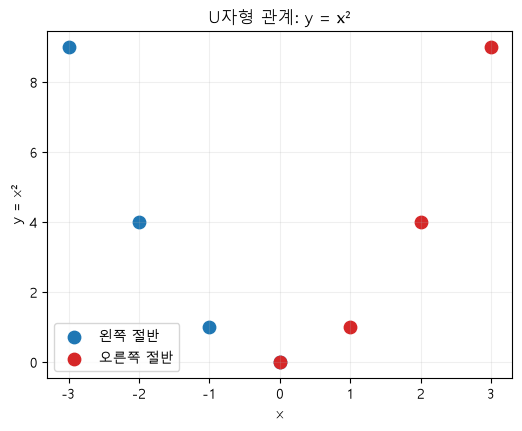

In [8]:
# U자형(비선형) 관계 확인

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

x_curve = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)
y_curve = x_curve ** 2

r_curve, p_curve = stats.pearsonr(x_curve, y_curve)

print("[U자형 관계 y = x²]")
print(f"r = {r_curve:.4f}, p-value = {p_curve:.4f}")

# 왼쪽 절반과 오른쪽 절반을 따로 계산
left_x, left_y = x_curve[:4], y_curve[:4]      # x = -3 ~ 0
right_x, right_y = x_curve[3:], y_curve[3:]    # x = 0 ~ 3

r_left, _ = stats.pearsonr(left_x, left_y)
r_right, _ = stats.pearsonr(right_x, right_y)

print(f"왼쪽 절반(x=-3~0) r = {r_left:.4f}")
print(f"오른쪽 절반(x=0~3) r = {r_right:.4f}")

plt.figure(figsize=(6, 4.5))
plt.scatter(left_x, left_y, s=80, color="tab:blue", label="왼쪽 절반")
plt.scatter(right_x, right_y, s=80, color="tab:red", label="오른쪽 절반")
plt.xlabel("x")
plt.ylabel("y = x²")
plt.title("U자형 관계: y = x²")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

---

## 실습 마무리

- 어떤 문제가 있었는가?
-> 상관계수와 p-value만으로는 관계를 명확하게 규정하기 어려움

- 어떻게 개선했는가?
-> r, r^2, p-value, 산점도, 이상치 유 / 무

- 무엇을 근거로 개선되었다고 판단했는가?
-> 이상치 값 하나로 r값과 p-value가 달라지는 것을 확인했다
-> 본 데이터의 이상치를 제거한다면 정상적인 r값과 p-value로 올바른 통계적 해석이 가능하다.

피어슨 상관계수의 숫자만 보았을 때 놓칠 수 있었던 점, 산점도와 인과적 관점을 추가해 해석이 어떻게 개선되었는지 정리하세요.
